In [3]:
# ------------------------------------------------------------
# Draw representative point sample for later extraction of
# forest age, DBH, height, cover, biomass, etc.
# ------------------------------------------------------------

from pathlib import Path
import numpy as np
import pandas as pd
import geopandas as gpd
import rasterio
from rasterio.vrt import WarpedVRT
from rasterio.enums import Resampling
from rasterio.windows import transform as window_transform
from tqdm.auto import tqdm

# ------------------------------------------------------------
# Paths
# ------------------------------------------------------------

out_dir = Path("/mnt/eo/EO4Backcasting/_analysis_cache")
out_dir.mkdir(parents=True, exist_ok=True)

prob_fp = Path(
    "/mnt/eo/EO4Backcasting/_predictions/predictions_global_model/"
    "mosaic_prob_predictions_global_model_zstd.tif"
)

forest_mask_fp = Path("/mnt/eo/EFDA_v211/forest_landuse_aligned.tif")

disturbance_fp = Path("/mnt/eo/EFDA_v211/yod_aligned.tif")

out_csv = out_dir / "sample_locations_continuity_disturbance_strata.csv"
out_gpkg = out_dir / "sample_locations_continuity_disturbance_strata.gpkg"

# ------------------------------------------------------------
# Settings
# ------------------------------------------------------------

forest_value = 1

disturbance_year_min = 1985
disturbance_year_max = 2024

random_seed = 42
rng = np.random.default_rng(random_seed)

n_per_stratum = 50_000
max_per_block = 500

prob_bins = [
    (0.00, 0.25, "no_recorded_disturbance_prob_000_025"),
    (0.25, 0.50, "no_recorded_disturbance_prob_025_050"),
    (0.50, 0.75, "no_recorded_disturbance_prob_050_075"),
    (0.75, 0.90, "no_recorded_disturbance_prob_075_090"),
    (0.90, 1.01, "no_recorded_disturbance_prob_090_100"),
]

strata = ["known_disturbed"] + [x[2] for x in prob_bins]

sample_parts = {s: [] for s in strata}
sample_counts = {s: 0 for s in strata}

# ------------------------------------------------------------
# Check inputs
# ------------------------------------------------------------

for fp in [prob_fp, forest_mask_fp, disturbance_fp]:
    if not fp.exists():
        raise FileNotFoundError(f"Missing file: {fp}")

print("Probability raster:", prob_fp)
print("Forest mask:", forest_mask_fp)
print("Disturbance raster:", disturbance_fp)

# ------------------------------------------------------------
# Sampling
# ------------------------------------------------------------

with rasterio.open(prob_fp) as prob_src, \
     rasterio.open(forest_mask_fp) as forest_src, \
     rasterio.open(disturbance_fp) as dist_src:

    target_crs = prob_src.crs

    print("Target CRS:", target_crs)
    print("Target bounds:", prob_src.bounds)
    print("Target shape:", prob_src.height, prob_src.width)

    forest_vrt = WarpedVRT(
        forest_src,
        crs=prob_src.crs,
        transform=prob_src.transform,
        width=prob_src.width,
        height=prob_src.height,
        resampling=Resampling.nearest
    )

    dist_vrt = WarpedVRT(
        dist_src,
        crs=prob_src.crs,
        transform=prob_src.transform,
        width=prob_src.width,
        height=prob_src.height,
        resampling=Resampling.nearest,
        src_nodata=dist_src.nodata,
        nodata=0
    )

    def add_samples(mask, stratum_name, window, prob, dist):
        current_n = sample_counts[stratum_name]
        remaining = n_per_stratum - current_n

        if remaining <= 0:
            return

        rows, cols = np.where(mask)
        n_available = len(rows)

        if n_available == 0:
            return

        n_take = min(n_available, remaining, max_per_block)

        idx = rng.choice(n_available, size=n_take, replace=False)
        rows_s = rows[idx]
        cols_s = cols[idx]

        win_transform = window_transform(window, prob_src.transform)

        xs, ys = rasterio.transform.xy(
            win_transform,
            rows_s,
            cols_s,
            offset="center"
        )

        df = pd.DataFrame({
            "x": np.array(xs),
            "y": np.array(ys),
            "continuity_probability": prob[rows_s, cols_s],
            "disturbance_year": dist[rows_s, cols_s],
            "sample_stratum": stratum_name
        })

        sample_parts[stratum_name].append(df)
        sample_counts[stratum_name] += n_take

    # ------------------------------------------------------------
    # Randomize raster block order to avoid spatial bias
    # ------------------------------------------------------------

    windows = list(prob_src.block_windows(1))
    rng.shuffle(windows)

    for _, window in tqdm(windows, desc="Sampling locations"):

        prob = prob_src.read(1, window=window).astype("float32")
        forest = forest_vrt.read(1, window=window)
        dist = dist_vrt.read(1, window=window).astype("float32")

        valid_forest = (
            (forest == forest_value) &
            np.isfinite(prob) &
            (prob >= 0) &
            (prob <= 1)
        )

        if not np.any(valid_forest):
            continue

        known_disturbed = (
            valid_forest &
            np.isfinite(dist) &
            (dist >= disturbance_year_min) &
            (dist <= disturbance_year_max)
        )

        no_recorded_disturbance = valid_forest & ~known_disturbed

        add_samples(
            known_disturbed,
            "known_disturbed",
            window,
            prob,
            dist
        )

        for lo, hi, label in prob_bins:
            mask = (
                no_recorded_disturbance &
                (prob >= lo) &
                (prob < hi)
            )

            add_samples(
                mask,
                label,
                window,
                prob,
                dist
            )

        if all(sample_counts[s] >= n_per_stratum for s in strata):
            break

    forest_vrt.close()
    dist_vrt.close()

# ------------------------------------------------------------
# Combine sample
# ------------------------------------------------------------

dfs = []

for s in strata:
    if len(sample_parts[s]) > 0:
        dfs.append(pd.concat(sample_parts[s], ignore_index=True))

if len(dfs) == 0:
    raise ValueError("No samples were drawn. Check forest mask, probability raster, and disturbance raster.")

df_sample = pd.concat(dfs, ignore_index=True)

# ------------------------------------------------------------
# Clean and classify
# ------------------------------------------------------------

df_sample["disturbance_year"] = np.where(
    (df_sample["disturbance_year"] >= disturbance_year_min) &
    (df_sample["disturbance_year"] <= disturbance_year_max),
    df_sample["disturbance_year"],
    np.nan
)

df_sample["disturbance_status"] = np.where(
    df_sample["disturbance_year"].notna(),
    "known_disturbed",
    "no_recorded_disturbance"
)

df_sample["probability_class"] = pd.cut(
    df_sample["continuity_probability"],
    bins=[0, 0.25, 0.50, 0.75, 0.90, 1.01],
    labels=["0.00–0.25", "0.25–0.50", "0.50–0.75", "0.75–0.90", "0.90–1.00"],
    include_lowest=True,
    right=False
)

df_sample.insert(0, "sample_id", np.arange(1, len(df_sample) + 1))

# ------------------------------------------------------------
# Save CSV and GeoPackage
# ------------------------------------------------------------

df_sample.to_csv(out_csv, index=False)

gdf_sample = gpd.GeoDataFrame(
    df_sample,
    geometry=gpd.points_from_xy(df_sample["x"], df_sample["y"]),
    crs=target_crs
)

if out_gpkg.exists():
    out_gpkg.unlink()

gdf_sample.to_file(out_gpkg, layer="sample_locations", driver="GPKG")

print("Saved CSV:", out_csv)
print("Saved GPKG:", out_gpkg)

print("\nSample counts:")
print(df_sample["sample_stratum"].value_counts())

display(df_sample.head())

Probability raster: /mnt/eo/EO4Backcasting/_predictions/predictions_global_model/mosaic_prob_predictions_global_model_zstd.tif
Forest mask: /mnt/eo/EFDA_v211/forest_landuse_aligned.tif
Disturbance raster: /mnt/eo/EFDA_v211/yod_aligned.tif
Target CRS: EPSG:3035
Target bounds: BoundingBox(left=2612197.933345846, bottom=1365550.4228236396, right=6512197.933345846, top=5565550.42282364)
Target shape: 140000 130000


Sampling locations:   0%|          | 0/277876 [00:00<?, ?it/s]

Saved CSV: /mnt/eo/EO4Backcasting/_analysis_cache/sample_locations_continuity_disturbance_strata.csv
Saved GPKG: /mnt/eo/EO4Backcasting/_analysis_cache/sample_locations_continuity_disturbance_strata.gpkg

Sample counts:
sample_stratum
known_disturbed                         50000
no_recorded_disturbance_prob_000_025    50000
no_recorded_disturbance_prob_025_050    50000
no_recorded_disturbance_prob_050_075    50000
no_recorded_disturbance_prob_075_090    50000
no_recorded_disturbance_prob_090_100    50000
Name: count, dtype: int64


,sample_id,x,y,continuity_probability,disturbance_year,sample_stratum,disturbance_status,probability_class
0,1,5.051093e+06,5.044825e+06,0.272635,2013.0,known_disturbed,known_disturbed,0.25–0.50
1,2,5.052053e+06,5.049475e+06,0.623304,2005.0,known_disturbed,known_disturbed,0.50–0.75
2,3,5.048063e+06,5.047315e+06,0.248824,2001.0,known_disturbed,known_disturbed,0.00–0.25
3,4,5.053643e+06,5.048845e+06,0.356671,2013.0,known_disturbed,known_disturbed,0.25–0.50
4,5,5.050643e+06,5.047405e+06,0.562632,2005.0,known_disturbed,known_disturbed,0.50–0.75


In [4]:
# ------------------------------------------------------------
# Extract forest age to stratified sample locations
# ------------------------------------------------------------

from pathlib import Path
import numpy as np
import geopandas as gpd
import rasterio
from tqdm.auto import tqdm

analysis_cache_dir = Path("/mnt/eo/EO4Backcasting/_analysis_cache")

sample_gpkg = analysis_cache_dir / "sample_locations_continuity_disturbance_strata.gpkg"

forest_age_fp = Path(
    "/mnt/eo/EO4Backcasting/_data_aligned/"
    "GAMIv2_1_forest_age_2020_member1_europe_100m_epsg4326.tif"
)

out_gpkg = analysis_cache_dir / "sample_locations_continuity_disturbance_strata_with_forest_age.gpkg"
out_csv = analysis_cache_dir / "sample_locations_continuity_disturbance_strata_with_forest_age.csv"

age_threshold = 55

gdf = gpd.read_file(sample_gpkg, layer="sample_locations")

with rasterio.open(forest_age_fp) as src:
    gdf_age_crs = gdf.to_crs(src.crs)

    coords = [(geom.x, geom.y) for geom in gdf_age_crs.geometry]

    values = np.full(len(coords), np.nan, dtype="float32")
    nodata = src.nodata

    chunk_size = 100_000

    for start in tqdm(range(0, len(coords), chunk_size), desc="Extracting forest age"):
        end = min(start + chunk_size, len(coords))

        vals = np.array(
            [v[0] for v in src.sample(coords[start:end])],
            dtype="float32"
        )

        if nodata is not None:
            vals = np.where(vals == nodata, np.nan, vals)

        vals = np.where(
            np.isfinite(vals) &
            (vals >= 0) &
            (vals <= 140),
            vals,
            np.nan
        )

        values[start:end] = vals

gdf["forest_age_2020"] = values
gdf["forest_age_ge_55"] = gdf["forest_age_2020"] >= age_threshold

if out_gpkg.exists():
    out_gpkg.unlink()

gdf.to_file(out_gpkg, layer="sample_locations", driver="GPKG")
gdf.drop(columns="geometry").to_csv(out_csv, index=False)

print("Saved:", out_gpkg)
print("Saved:", out_csv)

display(
    gdf
    .groupby("sample_stratum", observed=True)
    .agg(
        n=("sample_id", "size"),
        valid_age=("forest_age_2020", lambda x: x.notna().sum()),
        median_age=("forest_age_2020", "median"),
        q25_age=("forest_age_2020", lambda x: np.nanpercentile(x.dropna(), 25) if x.notna().sum() > 0 else np.nan),
        q75_age=("forest_age_2020", lambda x: np.nanpercentile(x.dropna(), 75) if x.notna().sum() > 0 else np.nan),
        share_age_ge_55=("forest_age_ge_55", "mean"),
        median_probability=("continuity_probability", "median")
    )
)

Extracting forest age:   0%|          | 0/3 [00:00<?, ?it/s]

Saved: /mnt/eo/EO4Backcasting/_analysis_cache/sample_locations_continuity_disturbance_strata_with_forest_age.gpkg
Saved: /mnt/eo/EO4Backcasting/_analysis_cache/sample_locations_continuity_disturbance_strata_with_forest_age.csv


,n,valid_age,median_age,q25_age,q75_age,share_age_ge_55,median_probability
sample_stratum,,,,,,,
known_disturbed,50000,33403,71.0,20.0,97.0,0.40754,0.568708
no_recorded_disturbance_prob_000_025,50000,37923,87.0,66.0,104.0,0.62930,0.198166
no_recorded_disturbance_prob_025_050,50000,35229,85.0,63.0,104.0,0.57012,0.425152
no_recorded_disturbance_prob_050_075,50000,31284,84.0,61.0,103.0,0.49490,0.595917
no_recorded_disturbance_prob_075_090,50000,26140,81.0,42.0,103.0,0.35346,0.800364
no_recorded_disturbance_prob_090_100,50000,27692,88.0,20.0,110.0,0.37056,0.916884


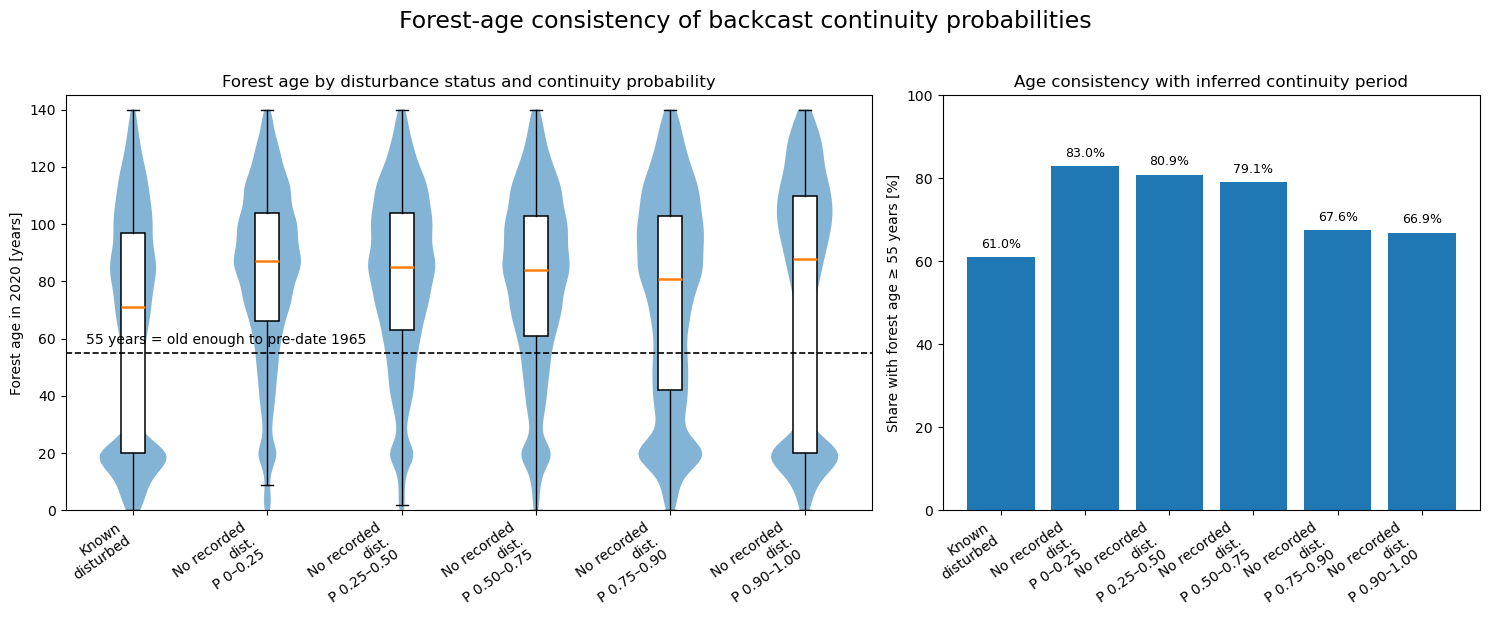

Saved: /mnt/eo/EO4Backcasting/_figures/forest_age_comparison/forest_age_distribution_and_share_ge55_by_probability_stratum.png
Saved: /mnt/eo/EO4Backcasting/_figures/forest_age_comparison/forest_age_distribution_and_share_ge55_by_probability_stratum.svg


In [5]:
# ------------------------------------------------------------
# Forest age comparison plot
# ------------------------------------------------------------

import numpy as np
import matplotlib.pyplot as plt
from pathlib import Path

fig_dir = Path("/mnt/eo/EO4Backcasting/_figures/forest_age_comparison")
fig_dir.mkdir(parents=True, exist_ok=True)

df_plot = gdf.dropna(subset=["forest_age_2020"]).copy()

order = [
    "known_disturbed",
    "no_recorded_disturbance_prob_000_025",
    "no_recorded_disturbance_prob_025_050",
    "no_recorded_disturbance_prob_050_075",
    "no_recorded_disturbance_prob_075_090",
    "no_recorded_disturbance_prob_090_100",
]

labels = [
    "Known\ndisturbed",
    "No recorded\ndist.\nP 0–0.25",
    "No recorded\ndist.\nP 0.25–0.50",
    "No recorded\ndist.\nP 0.50–0.75",
    "No recorded\ndist.\nP 0.75–0.90",
    "No recorded\ndist.\nP 0.90–1.00",
]

data = [
    df_plot.loc[df_plot["sample_stratum"] == s, "forest_age_2020"].values
    for s in order
]

summary = (
    df_plot
    .groupby("sample_stratum", observed=True)
    .agg(
        share_age_ge_55=("forest_age_ge_55", "mean"),
        median_age=("forest_age_2020", "median"),
        n=("forest_age_2020", "size")
    )
    .reindex(order)
    .reset_index()
)

summary["share_age_ge_55_percent"] = summary["share_age_ge_55"] * 100

fig, axes = plt.subplots(
    1, 2,
    figsize=(15, 6),
    gridspec_kw={"width_ratios": [1.5, 1]}
)

# Left: distribution
vp = axes[0].violinplot(
    data,
    showmeans=False,
    showmedians=False,
    showextrema=False
)

for body in vp["bodies"]:
    body.set_alpha(0.55)

axes[0].boxplot(
    data,
    widths=0.18,
    showfliers=False,
    patch_artist=True,
    medianprops={"linewidth": 1.8},
    boxprops={"facecolor": "white", "linewidth": 1.1},
    whiskerprops={"linewidth": 1.0},
    capprops={"linewidth": 1.0}
)

axes[0].axhline(
    55,
    linestyle="--",
    linewidth=1.2,
    color="black"
)

axes[0].text(
    0.65,
    57,
    "55 years = old enough to pre-date 1965",
    ha="left",
    va="bottom",
    fontsize=10
)

axes[0].set_xticks(np.arange(1, len(labels) + 1))
axes[0].set_xticklabels(labels, rotation=35, ha="right")
axes[0].set_ylabel("Forest age in 2020 [years]")
axes[0].set_title("Forest age by disturbance status and continuity probability")
axes[0].set_ylim(0, 145)

# Right: share age >= 55
x = np.arange(len(summary))

axes[1].bar(
    x,
    summary["share_age_ge_55_percent"]
)

axes[1].set_xticks(x)
axes[1].set_xticklabels(labels, rotation=35, ha="right")
axes[1].set_ylabel("Share with forest age ≥ 55 years [%]")
axes[1].set_title("Age consistency with inferred continuity period")
axes[1].set_ylim(0, 100)

for i, val in enumerate(summary["share_age_ge_55_percent"]):
    if np.isfinite(val):
        axes[1].text(
            i,
            val + 1.5,
            f"{val:.1f}%",
            ha="center",
            va="bottom",
            fontsize=9
        )

fig.suptitle(
    "Forest-age consistency of backcast continuity probabilities",
    fontsize=17,
    y=1.02
)

plt.tight_layout()

out_png = fig_dir / "forest_age_distribution_and_share_ge55_by_probability_stratum.png"
out_svg = fig_dir / "forest_age_distribution_and_share_ge55_by_probability_stratum.svg"

fig.savefig(out_png, dpi=500, bbox_inches="tight", facecolor="white")
fig.savefig(out_svg, bbox_inches="tight", facecolor="white")

plt.show()

print("Saved:", out_png)
print("Saved:", out_svg)

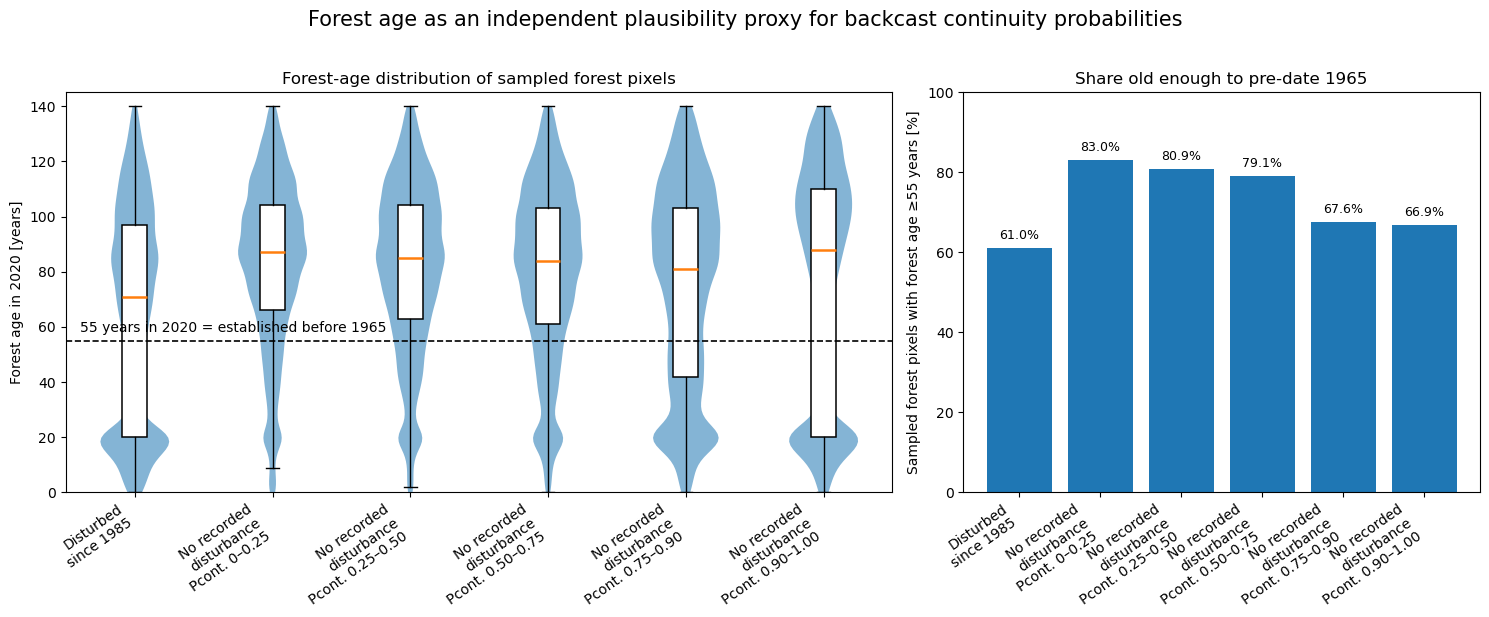

Saved: /mnt/eo/EO4Backcasting/_figures/forest_age_comparison/forest_age_by_disturbance_and_continuity_probability_improved_labels.png
Saved: /mnt/eo/EO4Backcasting/_figures/forest_age_comparison/forest_age_by_disturbance_and_continuity_probability_improved_labels.svg


In [6]:
# ------------------------------------------------------------
# Improved forest-age comparison plot
# ------------------------------------------------------------

import numpy as np
import matplotlib.pyplot as plt
from pathlib import Path

fig_dir = Path("/mnt/eo/EO4Backcasting/_figures/forest_age_comparison")
fig_dir.mkdir(parents=True, exist_ok=True)

df_plot = gdf.dropna(subset=["forest_age_2020"]).copy()

order = [
    "known_disturbed",
    "no_recorded_disturbance_prob_000_025",
    "no_recorded_disturbance_prob_025_050",
    "no_recorded_disturbance_prob_050_075",
    "no_recorded_disturbance_prob_075_090",
    "no_recorded_disturbance_prob_090_100",
]

labels = [
    "Disturbed\nsince 1985",
    "No recorded\ndisturbance\nPcont. 0–0.25",
    "No recorded\ndisturbance\nPcont. 0.25–0.50",
    "No recorded\ndisturbance\nPcont. 0.50–0.75",
    "No recorded\ndisturbance\nPcont. 0.75–0.90",
    "No recorded\ndisturbance\nPcont. 0.90–1.00",
]

data = [
    df_plot.loc[df_plot["sample_stratum"] == s, "forest_age_2020"].values
    for s in order
]

summary = (
    df_plot
    .groupby("sample_stratum", observed=True)
    .agg(
        share_age_ge_55=("forest_age_ge_55", "mean"),
        median_age=("forest_age_2020", "median"),
        n=("forest_age_2020", "size")
    )
    .reindex(order)
    .reset_index()
)

summary["share_age_ge_55_percent"] = summary["share_age_ge_55"] * 100

fig, axes = plt.subplots(
    1, 2,
    figsize=(15, 6),
    gridspec_kw={"width_ratios": [1.6, 1]}
)

# ------------------------------------------------------------
# Left: forest-age distributions
# ------------------------------------------------------------

vp = axes[0].violinplot(
    data,
    showmeans=False,
    showmedians=False,
    showextrema=False
)

for body in vp["bodies"]:
    body.set_alpha(0.55)

axes[0].boxplot(
    data,
    widths=0.18,
    showfliers=False,
    patch_artist=True,
    medianprops={"linewidth": 1.8},
    boxprops={"facecolor": "white", "linewidth": 1.1},
    whiskerprops={"linewidth": 1.0},
    capprops={"linewidth": 1.0}
)

axes[0].axhline(
    55,
    linestyle="--",
    linewidth=1.2,
    color="black"
)

axes[0].text(
    0.6,
    57,
    "55 years in 2020 = established before 1965",
    ha="left",
    va="bottom",
    fontsize=10
)

axes[0].set_xticks(np.arange(1, len(labels) + 1))
axes[0].set_xticklabels(labels, rotation=35, ha="right")

axes[0].set_ylabel("Forest age in 2020 [years]")
axes[0].set_title(
    "Forest-age distribution of sampled forest pixels",
    fontsize=12
)
axes[0].set_ylim(0, 145)

# ------------------------------------------------------------
# Right: share age >= 55
# ------------------------------------------------------------

x = np.arange(len(summary))

axes[1].bar(
    x,
    summary["share_age_ge_55_percent"]
)

axes[1].set_xticks(x)
axes[1].set_xticklabels(labels, rotation=35, ha="right")

axes[1].set_ylabel("Sampled forest pixels with forest age ≥55 years [%]")
axes[1].set_title(
    "Share old enough to pre-date 1965",
    fontsize=12
)
axes[1].set_ylim(0, 100)

for i, val in enumerate(summary["share_age_ge_55_percent"]):
    if np.isfinite(val):
        axes[1].text(
            i,
            val + 1.5,
            f"{val:.1f}%",
            ha="center",
            va="bottom",
            fontsize=9
        )

fig.suptitle(
    "Forest age as an independent plausibility proxy for backcast continuity probabilities",
    fontsize=15,
    y=1.02
)

plt.tight_layout()

out_png = fig_dir / "forest_age_by_disturbance_and_continuity_probability_improved_labels.png"
out_svg = fig_dir / "forest_age_by_disturbance_and_continuity_probability_improved_labels.svg"

fig.savefig(out_png, dpi=500, bbox_inches="tight", facecolor="white")
fig.savefig(out_svg, bbox_inches="tight", facecolor="white")

plt.show()

print("Saved:", out_png)
print("Saved:", out_svg)

In [7]:
# ------------------------------------------------------------
# Draw stratified point sample consistent with forest-age map 2020
# ------------------------------------------------------------
# Groups:
# 1) Disturbed 1985–2020
# 2) Disturbed 2021–2024
# 3) No recorded disturbance until 2020, stratified by continuity probability
#
# Output:
# - CSV
# - GeoPackage
# ------------------------------------------------------------

from pathlib import Path
import numpy as np
import pandas as pd
import geopandas as gpd
import rasterio
from rasterio.vrt import WarpedVRT
from rasterio.enums import Resampling
from rasterio.windows import transform as window_transform
from tqdm.auto import tqdm

# ------------------------------------------------------------
# Paths
# ------------------------------------------------------------

out_dir = Path("/mnt/eo/EO4Backcasting/_analysis_cache")
out_dir.mkdir(parents=True, exist_ok=True)

prob_fp = Path(
    "/mnt/eo/EO4Backcasting/_predictions/predictions_global_model/"
    "mosaic_prob_predictions_global_model_zstd.tif"
)

forest_mask_fp = Path("/mnt/eo/EFDA_v211/forest_landuse_aligned.tif")

# Disturbance year raster:
# values = year of disturbance, e.g. 1985–2024
# 0 or nodata = no recorded disturbance
disturbance_fp = Path("/mnt/eo/EFDA_v211/yod_aligned.tif")

out_csv = out_dir / "sample_locations_continuity_disturbance_strata_age2020_consistent.csv"
out_gpkg = out_dir / "sample_locations_continuity_disturbance_strata_age2020_consistent.gpkg"

# ------------------------------------------------------------
# Settings
# ------------------------------------------------------------

forest_value = 1

forest_age_reference_year = 2020
disturbance_year_min = 1985
disturbance_year_max = 2024

random_seed = 42
rng = np.random.default_rng(random_seed)

# samples per group
n_per_stratum = 50_000

# limit per raster block so one spatial block does not dominate
max_per_block = 500

prob_bins = [
    (0.00, 0.25, "no_dist_until_2020_prob_000_025"),
    (0.25, 0.50, "no_dist_until_2020_prob_025_050"),
    (0.50, 0.75, "no_dist_until_2020_prob_050_075"),
    (0.75, 0.90, "no_dist_until_2020_prob_075_090"),
    (0.90, 1.01, "no_dist_until_2020_prob_090_100"),
]

strata = [
    "disturbed_1985_2020",
    "disturbed_2021_2024",
] + [x[2] for x in prob_bins]

sample_parts = {s: [] for s in strata}
sample_counts = {s: 0 for s in strata}

# ------------------------------------------------------------
# Check inputs
# ------------------------------------------------------------

for fp in [prob_fp, forest_mask_fp, disturbance_fp]:
    if not fp.exists():
        raise FileNotFoundError(f"Missing file: {fp}")

print("Probability raster:", prob_fp)
print("Forest mask:", forest_mask_fp)
print("Disturbance raster:", disturbance_fp)
print("Output CSV:", out_csv)
print("Output GPKG:", out_gpkg)

# ------------------------------------------------------------
# Sampling
# ------------------------------------------------------------

with rasterio.open(prob_fp) as prob_src, \
     rasterio.open(forest_mask_fp) as forest_src, \
     rasterio.open(disturbance_fp) as dist_src:

    target_crs = prob_src.crs

    print("\nTarget CRS:", target_crs)
    print("Target bounds:", prob_src.bounds)
    print("Target shape:", prob_src.height, prob_src.width)

    # Align forest mask to probability grid
    forest_vrt = WarpedVRT(
        forest_src,
        crs=prob_src.crs,
        transform=prob_src.transform,
        width=prob_src.width,
        height=prob_src.height,
        resampling=Resampling.nearest
    )

    # Align disturbance year raster to probability grid
    dist_vrt = WarpedVRT(
        dist_src,
        crs=prob_src.crs,
        transform=prob_src.transform,
        width=prob_src.width,
        height=prob_src.height,
        resampling=Resampling.nearest,
        src_nodata=dist_src.nodata,
        nodata=0
    )

    def add_samples(mask, stratum_name, window, prob, dist):
        current_n = sample_counts[stratum_name]
        remaining = n_per_stratum - current_n

        if remaining <= 0:
            return

        rows, cols = np.where(mask)
        n_available = len(rows)

        if n_available == 0:
            return

        n_take = min(n_available, remaining, max_per_block)

        idx = rng.choice(n_available, size=n_take, replace=False)
        rows_s = rows[idx]
        cols_s = cols[idx]

        win_transform = window_transform(window, prob_src.transform)

        xs, ys = rasterio.transform.xy(
            win_transform,
            rows_s,
            cols_s,
            offset="center"
        )

        dist_vals = dist[rows_s, cols_s]

        df = pd.DataFrame({
            "x": np.array(xs),
            "y": np.array(ys),
            "continuity_probability": prob[rows_s, cols_s],
            "disturbance_year_raw": dist_vals,
            "sample_stratum": stratum_name
        })

        sample_parts[stratum_name].append(df)
        sample_counts[stratum_name] += n_take

    # ------------------------------------------------------------
    # Randomize raster block order to avoid spatial bias
    # ------------------------------------------------------------

    windows = list(prob_src.block_windows(1))
    rng.shuffle(windows)

    for _, window in tqdm(windows, desc="Sampling locations"):

        prob = prob_src.read(1, window=window).astype("float32")
        forest = forest_vrt.read(1, window=window)
        dist = dist_vrt.read(1, window=window).astype("float32")

        valid_forest = (
            (forest == forest_value) &
            np.isfinite(prob) &
            (prob >= 0) &
            (prob <= 1)
        )

        if not np.any(valid_forest):
            continue

        valid_dist_year = (
            np.isfinite(dist) &
            (dist >= disturbance_year_min) &
            (dist <= disturbance_year_max)
        )

        # Disturbed before or in the reference year of the forest-age map.
        # These disturbances could theoretically be reflected in forest_age_2020.
        disturbed_1985_2020 = (
            valid_forest &
            valid_dist_year &
            (dist <= forest_age_reference_year)
        )

        # Disturbed after the forest-age reference year.
        # These should not necessarily be visible in forest_age_2020.
        disturbed_2021_2024 = (
            valid_forest &
            valid_dist_year &
            (dist > forest_age_reference_year)
        )

        # No recorded disturbance until 2020.
        # Pixels disturbed after 2020 are excluded from this group because
        # they were still undisturbed at the forest-age reference year,
        # but are a separate control group above.
        no_recorded_disturbance_until_2020 = (
            valid_forest &
            (
                ~valid_dist_year |
                (dist == 0)
            )
        )

        # Sample disturbed 1985–2020
        add_samples(
            disturbed_1985_2020,
            "disturbed_1985_2020",
            window,
            prob,
            dist
        )

        # Sample disturbed 2021–2024
        add_samples(
            disturbed_2021_2024,
            "disturbed_2021_2024",
            window,
            prob,
            dist
        )

        # Sample no recorded disturbance until 2020 by probability bins
        for lo, hi, label in prob_bins:
            mask = (
                no_recorded_disturbance_until_2020 &
                (prob >= lo) &
                (prob < hi)
            )

            add_samples(
                mask,
                label,
                window,
                prob,
                dist
            )

        if all(sample_counts[s] >= n_per_stratum for s in strata):
            break

    forest_vrt.close()
    dist_vrt.close()

# ------------------------------------------------------------
# Combine sample
# ------------------------------------------------------------

dfs = []

for s in strata:
    if len(sample_parts[s]) > 0:
        dfs.append(pd.concat(sample_parts[s], ignore_index=True))

if len(dfs) == 0:
    raise ValueError(
        "No samples were drawn. Check forest mask, probability raster, and disturbance raster."
    )

df_sample = pd.concat(dfs, ignore_index=True)

# ------------------------------------------------------------
# Clean and classify
# ------------------------------------------------------------

df_sample["disturbance_year"] = np.where(
    (df_sample["disturbance_year_raw"] >= disturbance_year_min) &
    (df_sample["disturbance_year_raw"] <= disturbance_year_max),
    df_sample["disturbance_year_raw"],
    np.nan
)

df_sample["disturbance_period"] = np.select(
    [
        (df_sample["disturbance_year"] >= disturbance_year_min) &
        (df_sample["disturbance_year"] <= forest_age_reference_year),

        (df_sample["disturbance_year"] > forest_age_reference_year) &
        (df_sample["disturbance_year"] <= disturbance_year_max),
    ],
    [
        "disturbed_1985_2020",
        "disturbed_2021_2024",
    ],
    default="no_recorded_disturbance_until_2020"
)

df_sample["disturbance_status_2020"] = np.where(
    df_sample["disturbance_period"] == "disturbed_1985_2020",
    "disturbed_until_2020",
    "not_disturbed_until_2020"
)

df_sample["probability_class"] = pd.cut(
    df_sample["continuity_probability"],
    bins=[0, 0.25, 0.50, 0.75, 0.90, 1.01],
    labels=["0.00–0.25", "0.25–0.50", "0.50–0.75", "0.75–0.90", "0.90–1.00"],
    include_lowest=True,
    right=False
)

# This is useful later when comparing disturbance year with forest_age_2020
df_sample["years_since_disturbance_2020"] = np.where(
    df_sample["disturbance_period"] == "disturbed_1985_2020",
    forest_age_reference_year - df_sample["disturbance_year"],
    np.nan
)

df_sample.insert(0, "sample_id", np.arange(1, len(df_sample) + 1))

# ------------------------------------------------------------
# Save CSV and GeoPackage
# ------------------------------------------------------------

df_sample.to_csv(out_csv, index=False)

gdf_sample = gpd.GeoDataFrame(
    df_sample,
    geometry=gpd.points_from_xy(df_sample["x"], df_sample["y"]),
    crs=target_crs
)

if out_gpkg.exists():
    out_gpkg.unlink()

gdf_sample.to_file(out_gpkg, layer="sample_locations", driver="GPKG")

print("\nSaved CSV:", out_csv)
print("Saved GPKG:", out_gpkg)

print("\nSample counts:")
print(df_sample["sample_stratum"].value_counts())

print("\nDisturbance period counts:")
print(df_sample["disturbance_period"].value_counts())

display(df_sample.head())

Probability raster: /mnt/eo/EO4Backcasting/_predictions/predictions_global_model/mosaic_prob_predictions_global_model_zstd.tif
Forest mask: /mnt/eo/EFDA_v211/forest_landuse_aligned.tif
Disturbance raster: /mnt/eo/EFDA_v211/yod_aligned.tif
Output CSV: /mnt/eo/EO4Backcasting/_analysis_cache/sample_locations_continuity_disturbance_strata_age2020_consistent.csv
Output GPKG: /mnt/eo/EO4Backcasting/_analysis_cache/sample_locations_continuity_disturbance_strata_age2020_consistent.gpkg

Target CRS: EPSG:3035
Target bounds: BoundingBox(left=2612197.933345846, bottom=1365550.4228236396, right=6512197.933345846, top=5565550.42282364)
Target shape: 140000 130000


Sampling locations:   0%|          | 0/277876 [00:00<?, ?it/s]


Saved CSV: /mnt/eo/EO4Backcasting/_analysis_cache/sample_locations_continuity_disturbance_strata_age2020_consistent.csv
Saved GPKG: /mnt/eo/EO4Backcasting/_analysis_cache/sample_locations_continuity_disturbance_strata_age2020_consistent.gpkg

Sample counts:
sample_stratum
disturbed_1985_2020                50000
disturbed_2021_2024                50000
no_dist_until_2020_prob_000_025    50000
no_dist_until_2020_prob_025_050    50000
no_dist_until_2020_prob_050_075    50000
no_dist_until_2020_prob_075_090    50000
no_dist_until_2020_prob_090_100    50000
Name: count, dtype: int64

Disturbance period counts:
disturbance_period
no_recorded_disturbance_until_2020    250000
disturbed_1985_2020                    50000
disturbed_2021_2024                    50000
Name: count, dtype: int64


,sample_id,x,y,continuity_probability,disturbance_year_raw,sample_stratum,disturbance_year,disturbance_period,disturbance_status_2020,probability_class,years_since_disturbance_2020
0,1,5.053913e+06,5.043385e+06,0.539803,2016.0,disturbed_1985_2020,2016.0,disturbed_1985_2020,disturbed_until_2020,0.50–0.75,4.0
1,2,5.053943e+06,5.049565e+06,0.541386,2013.0,disturbed_1985_2020,2013.0,disturbed_1985_2020,disturbed_until_2020,0.50–0.75,7.0
2,3,5.048003e+06,5.047405e+06,0.396540,2001.0,disturbed_1985_2020,2001.0,disturbed_1985_2020,disturbed_until_2020,0.25–0.50,19.0
3,4,5.050853e+06,5.048875e+06,0.459499,2020.0,disturbed_1985_2020,2020.0,disturbed_1985_2020,disturbed_until_2020,0.25–0.50,0.0
4,5,5.047553e+06,5.047495e+06,0.446770,2001.0,disturbed_1985_2020,2001.0,disturbed_1985_2020,disturbed_until_2020,0.25–0.50,19.0


In [8]:
# ------------------------------------------------------------
# Extract forest age 2020 to age-consistent stratified sample
# ------------------------------------------------------------

from pathlib import Path
import numpy as np
import pandas as pd
import geopandas as gpd
import rasterio
from tqdm.auto import tqdm

# ------------------------------------------------------------
# Paths
# ------------------------------------------------------------

analysis_cache_dir = Path("/mnt/eo/EO4Backcasting/_analysis_cache")

sample_gpkg = (
    analysis_cache_dir /
    "sample_locations_continuity_disturbance_strata_age2020_consistent.gpkg"
)

forest_age_fp = Path(
    "/mnt/eo/EO4Backcasting/_data_aligned/"
    "GAMIv2_1_forest_age_2020_member1_europe_100m_epsg4326.tif"
)

out_gpkg = (
    analysis_cache_dir /
    "sample_locations_continuity_disturbance_strata_age2020_consistent_with_forest_age.gpkg"
)

out_csv = (
    analysis_cache_dir /
    "sample_locations_continuity_disturbance_strata_age2020_consistent_with_forest_age.csv"
)

# ------------------------------------------------------------
# Settings
# ------------------------------------------------------------

forest_age_reference_year = 2020
backcast_start_year = 1965
age_threshold = forest_age_reference_year - backcast_start_year  # 55

chunk_size = 100_000

# ------------------------------------------------------------
# Checks
# ------------------------------------------------------------

if not sample_gpkg.exists():
    raise FileNotFoundError(f"Sample GPKG not found: {sample_gpkg}")

if not forest_age_fp.exists():
    raise FileNotFoundError(f"Forest-age raster not found: {forest_age_fp}")

print("Sample:", sample_gpkg)
print("Forest-age raster:", forest_age_fp)
print("Age threshold:", age_threshold)

# ------------------------------------------------------------
# Load sample
# ------------------------------------------------------------

gdf = gpd.read_file(sample_gpkg, layer="sample_locations")

print("Loaded sample points:", len(gdf))
print("Sample CRS:", gdf.crs)

print("\nSample strata:")
print(gdf["sample_stratum"].value_counts())

# ------------------------------------------------------------
# Extract forest age values
# ------------------------------------------------------------

with rasterio.open(forest_age_fp) as src:
    print("\nForest-age raster CRS:", src.crs)
    print("Forest-age raster bounds:", src.bounds)
    print("Forest-age raster nodata:", src.nodata)

    # Reproject sample points to raster CRS
    gdf_age_crs = gdf.to_crs(src.crs)

    coords = [(geom.x, geom.y) for geom in gdf_age_crs.geometry]

    values = np.full(len(coords), np.nan, dtype="float32")
    nodata = src.nodata

    for start in tqdm(
        range(0, len(coords), chunk_size),
        desc="Extracting forest age"
    ):
        end = min(start + chunk_size, len(coords))

        vals = np.array(
            [v[0] for v in src.sample(coords[start:end])],
            dtype="float32"
        )

        if nodata is not None:
            vals = np.where(vals == nodata, np.nan, vals)

        # Keep only plausible forest-age values
        vals = np.where(
            np.isfinite(vals) &
            (vals >= 0) &
            (vals <= 140),
            vals,
            np.nan
        )

        values[start:end] = vals

# ------------------------------------------------------------
# Add forest-age columns
# ------------------------------------------------------------

gdf["forest_age_2020"] = values
gdf["forest_age_ge_55"] = gdf["forest_age_2020"] >= age_threshold

# For disturbed pixels before/in 2020:
# expected stand age in 2020 if disturbance caused stand replacement.
if "years_since_disturbance_2020" in gdf.columns:
    gdf["age_minus_years_since_disturbance_2020"] = (
        gdf["forest_age_2020"] -
        gdf["years_since_disturbance_2020"]
    )
else:
    gdf["age_minus_years_since_disturbance_2020"] = np.nan

# Optional readable labels for later plotting
label_map = {
    "disturbed_1985_2020": "Disturbed 1985–2020",
    "disturbed_2021_2024": "Disturbed 2021–2024",
    "no_dist_until_2020_prob_000_025": "No disturbance until 2020\nPcont. 0–0.25",
    "no_dist_until_2020_prob_025_050": "No disturbance until 2020\nPcont. 0.25–0.50",
    "no_dist_until_2020_prob_050_075": "No disturbance until 2020\nPcont. 0.50–0.75",
    "no_dist_until_2020_prob_075_090": "No disturbance until 2020\nPcont. 0.75–0.90",
    "no_dist_until_2020_prob_090_100": "No disturbance until 2020\nPcont. 0.90–1.00",
}

gdf["plot_group"] = gdf["sample_stratum"].map(label_map)

# ------------------------------------------------------------
# Summary checks
# ------------------------------------------------------------

order = [
    "disturbed_1985_2020",
    "disturbed_2021_2024",
    "no_dist_until_2020_prob_000_025",
    "no_dist_until_2020_prob_025_050",
    "no_dist_until_2020_prob_050_075",
    "no_dist_until_2020_prob_075_090",
    "no_dist_until_2020_prob_090_100",
]

summary = (
    gdf
    .groupby("sample_stratum", observed=True)
    .agg(
        n=("sample_id", "size"),
        valid_age=("forest_age_2020", lambda x: x.notna().sum()),
        median_age=("forest_age_2020", "median"),
        q25_age=("forest_age_2020", lambda x: np.nanpercentile(x.dropna(), 25) if x.notna().sum() > 0 else np.nan),
        q75_age=("forest_age_2020", lambda x: np.nanpercentile(x.dropna(), 75) if x.notna().sum() > 0 else np.nan),
        share_age_ge_55=("forest_age_ge_55", "mean"),
        median_probability=("continuity_probability", "median"),
        median_disturbance_year=("disturbance_year", "median"),
        median_ysd_2020=("years_since_disturbance_2020", "median"),
        median_age_minus_ysd=("age_minus_years_since_disturbance_2020", "median")
    )
    .reindex(order)
    .reset_index()
)

summary["share_age_ge_55_percent"] = summary["share_age_ge_55"] * 100

display(summary)

print("\nValid forest-age values overall:")
print(gdf["forest_age_2020"].notna().sum(), "of", len(gdf))

print("\nForest-age summary:")
print(gdf["forest_age_2020"].describe())

# ------------------------------------------------------------
# Save
# ------------------------------------------------------------

if out_gpkg.exists():
    out_gpkg.unlink()

gdf.to_file(out_gpkg, layer="sample_locations", driver="GPKG")
gdf.drop(columns="geometry").to_csv(out_csv, index=False)

print("\nSaved GPKG:", out_gpkg)
print("Saved CSV:", out_csv)

Sample: /mnt/eo/EO4Backcasting/_analysis_cache/sample_locations_continuity_disturbance_strata_age2020_consistent.gpkg
Forest-age raster: /mnt/eo/EO4Backcasting/_data_aligned/GAMIv2_1_forest_age_2020_member1_europe_100m_epsg4326.tif
Age threshold: 55
Loaded sample points: 350000
Sample CRS: EPSG:3035

Sample strata:
sample_stratum
disturbed_1985_2020                50000
disturbed_2021_2024                50000
no_dist_until_2020_prob_000_025    50000
no_dist_until_2020_prob_025_050    50000
no_dist_until_2020_prob_050_075    50000
no_dist_until_2020_prob_075_090    50000
no_dist_until_2020_prob_090_100    50000
Name: count, dtype: int64

Forest-age raster CRS: EPSG:4326
Forest-age raster bounds: BoundingBox(left=-11.000000000000004, bottom=34.0, right=35.0, top=72.0)
Forest-age raster nodata: -9999.0


Extracting forest age:   0%|          | 0/4 [00:00<?, ?it/s]

,sample_stratum,n,valid_age,median_age,q25_age,q75_age,share_age_ge_55,median_probability,median_disturbance_year,median_ysd_2020,median_age_minus_ysd,share_age_ge_55_percent
0,disturbed_1985_2020,50000,33598,69.0,20.0,96.0,0.40040,0.570695,2002.0,18.0,48.0,40.040
1,disturbed_2021_2024,50000,32703,83.0,53.0,103.0,0.48310,0.568125,2022.0,NaN,NaN,48.310
2,no_dist_until_2020_prob_000_025,50000,37934,87.0,66.0,104.0,0.62896,0.198245,NaN,NaN,NaN,62.896
3,no_dist_until_2020_prob_025_050,50000,35221,85.0,63.0,104.0,0.56968,0.424712,NaN,NaN,NaN,56.968
4,no_dist_until_2020_prob_050_075,50000,31282,84.0,61.0,103.0,0.49448,0.595474,NaN,NaN,NaN,49.448
5,no_dist_until_2020_prob_075_090,50000,26063,81.0,43.0,103.0,0.35376,0.800247,NaN,NaN,NaN,35.376
6,no_dist_until_2020_prob_090_100,50000,27667,88.0,20.0,109.0,0.37098,0.916815,NaN,NaN,NaN,37.098



Valid forest-age values overall:
224468 of 350000

Forest-age summary:
count    224468.000000
mean         76.452881
std          35.324532
min           0.000000
25%          52.000000
50%          83.000000
75%         103.000000
max         140.000000
Name: forest_age_2020, dtype: float64

Saved GPKG: /mnt/eo/EO4Backcasting/_analysis_cache/sample_locations_continuity_disturbance_strata_age2020_consistent_with_forest_age.gpkg
Saved CSV: /mnt/eo/EO4Backcasting/_analysis_cache/sample_locations_continuity_disturbance_strata_age2020_consistent_with_forest_age.csv


In [9]:
# ------------------------------------------------------------
# Plot forest age comparison for age-2020-consistent sample
# ------------------------------------------------------------

from pathlib import Path
import numpy as np
import pandas as pd
import geopandas as gpd
import matplotlib.pyplot as plt

# ------------------------------------------------------------
# Paths
# ------------------------------------------------------------

analysis_cache_dir = Path("/mnt/eo/EO4Backcasting/_analysis_cache")
fig_dir = Path("/mnt/eo/EO4Backcasting/_figures/forest_age_comparison")
fig_dir.mkdir(parents=True, exist_ok=True)

sample_age_gpkg = (
    analysis_cache_dir /
    "sample_locations_continuity_disturbance_strata_age2020_consistent_with_forest_age.gpkg"
)

# ------------------------------------------------------------
# Load data
# ------------------------------------------------------------

gdf = gpd.read_file(sample_age_gpkg, layer="sample_locations")

print("Loaded:", len(gdf))
print(gdf.columns)
print(gdf["sample_stratum"].value_counts())

# ------------------------------------------------------------
# Settings
# ------------------------------------------------------------

age_threshold = 55

order = [
    "disturbed_1985_2020",
    "disturbed_2021_2024",
    "no_dist_until_2020_prob_000_025",
    "no_dist_until_2020_prob_025_050",
    "no_dist_until_2020_prob_050_075",
    "no_dist_until_2020_prob_075_090",
    "no_dist_until_2020_prob_090_100",
]

labels = [
    "Disturbed\n1985–2020",
    "Disturbed\n2021–2024",
    "No disturbance\nuntil 2020\nPcont. 0–0.25",
    "No disturbance\nuntil 2020\nPcont. 0.25–0.50",
    "No disturbance\nuntil 2020\nPcont. 0.50–0.75",
    "No disturbance\nuntil 2020\nPcont. 0.75–0.90",
    "No disturbance\nuntil 2020\nPcont. 0.90–1.00",
]

df_plot = gdf.dropna(subset=["forest_age_2020"]).copy()

# Ensure ordered category for summaries
df_plot["sample_stratum"] = pd.Categorical(
    df_plot["sample_stratum"],
    categories=order,
    ordered=True
)

summary = (
    df_plot
    .groupby("sample_stratum", observed=True)
    .agg(
        n=("forest_age_2020", "size"),
        median_age=("forest_age_2020", "median"),
        q25_age=("forest_age_2020", lambda x: np.nanpercentile(x, 25)),
        q75_age=("forest_age_2020", lambda x: np.nanpercentile(x, 75)),
        share_age_ge_55=("forest_age_ge_55", "mean"),
        median_probability=("continuity_probability", "median"),
        median_disturbance_year=("disturbance_year", "median"),
        median_ysd_2020=("years_since_disturbance_2020", "median"),
        median_age_minus_ysd=("age_minus_years_since_disturbance_2020", "median")
    )
    .reindex(order)
    .reset_index()
)

summary["share_age_ge_55_percent"] = summary["share_age_ge_55"] * 100

display(summary)

Loaded: 350000
Index(['sample_id', 'x', 'y', 'continuity_probability', 'disturbance_year_raw',
       'sample_stratum', 'disturbance_year', 'disturbance_period',
       'disturbance_status_2020', 'probability_class',
       'years_since_disturbance_2020', 'forest_age_2020', 'forest_age_ge_55',
       'age_minus_years_since_disturbance_2020', 'plot_group', 'geometry'],
      dtype='str')
sample_stratum
disturbed_1985_2020                50000
disturbed_2021_2024                50000
no_dist_until_2020_prob_000_025    50000
no_dist_until_2020_prob_025_050    50000
no_dist_until_2020_prob_050_075    50000
no_dist_until_2020_prob_075_090    50000
no_dist_until_2020_prob_090_100    50000
Name: count, dtype: int64


,sample_stratum,n,median_age,q25_age,q75_age,share_age_ge_55,median_probability,median_disturbance_year,median_ysd_2020,median_age_minus_ysd,share_age_ge_55_percent
0,disturbed_1985_2020,33598,69.0,20.0,96.0,0.595869,0.592361,2000.0,20.0,48.0,59.586880
1,disturbed_2021_2024,32703,83.0,53.0,103.0,0.738617,0.575264,2022.0,NaN,NaN,73.861725
2,no_dist_until_2020_prob_000_025,37934,87.0,66.0,104.0,0.829019,0.196412,NaN,NaN,NaN,82.901882
3,no_dist_until_2020_prob_025_050,35221,85.0,63.0,104.0,0.808722,0.422054,NaN,NaN,NaN,80.872207
4,no_dist_until_2020_prob_050_075,31282,84.0,61.0,103.0,0.790359,0.596187,NaN,NaN,NaN,79.035867
5,no_dist_until_2020_prob_075_090,26063,81.0,43.0,103.0,0.678663,0.799226,NaN,NaN,NaN,67.866324
6,no_dist_until_2020_prob_090_100,27667,88.0,20.0,109.0,0.670438,0.916851,NaN,NaN,NaN,67.043771


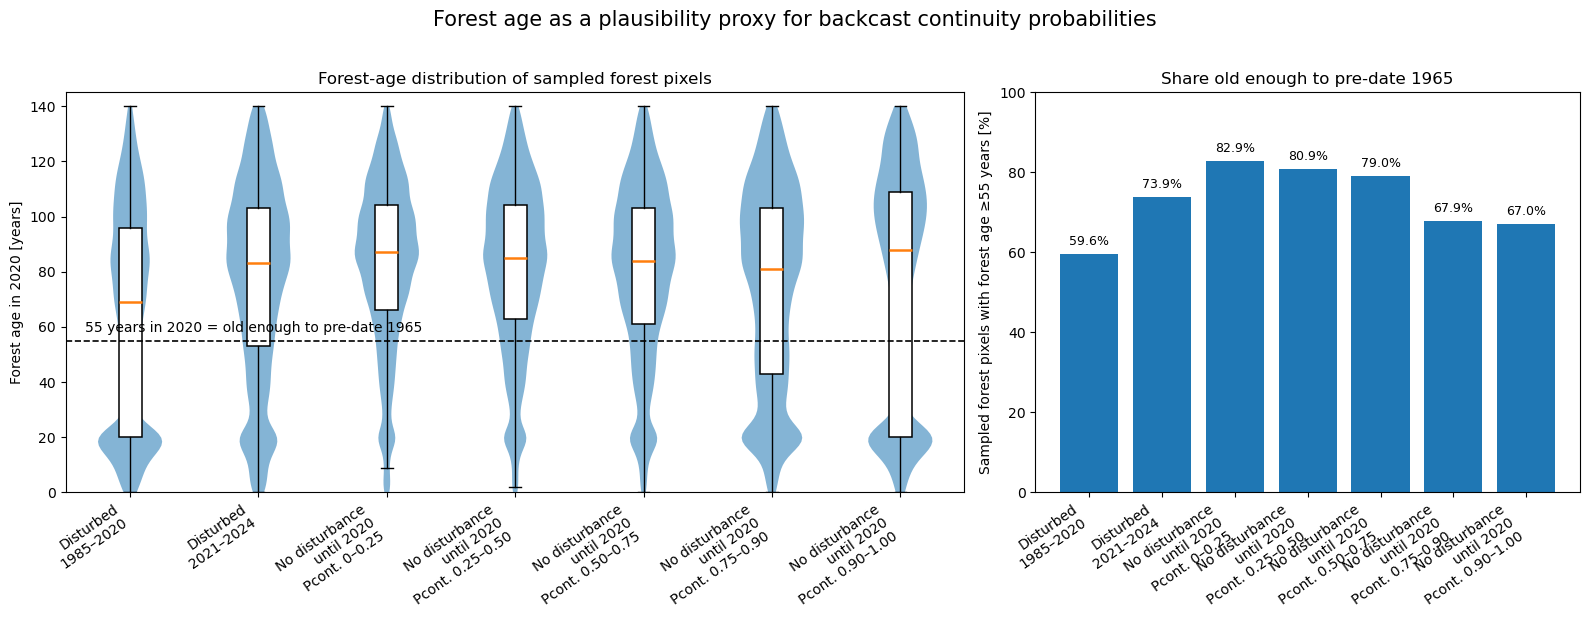

Saved: /mnt/eo/EO4Backcasting/_figures/forest_age_comparison/forest_age_by_disturbance_period_and_continuity_probability.png
Saved: /mnt/eo/EO4Backcasting/_figures/forest_age_comparison/forest_age_by_disturbance_period_and_continuity_probability.svg


In [10]:
# ------------------------------------------------------------
# Figure 1: Forest-age distributions + share age >= 55
# ------------------------------------------------------------

data = [
    df_plot.loc[df_plot["sample_stratum"] == s, "forest_age_2020"].values
    for s in order
]

fig, axes = plt.subplots(
    1, 2,
    figsize=(16, 6),
    gridspec_kw={"width_ratios": [1.65, 1]}
)

# ------------------------------------------------------------
# Left: violin + boxplot
# ------------------------------------------------------------

vp = axes[0].violinplot(
    data,
    showmeans=False,
    showmedians=False,
    showextrema=False
)

for body in vp["bodies"]:
    body.set_alpha(0.55)

axes[0].boxplot(
    data,
    widths=0.18,
    showfliers=False,
    patch_artist=True,
    medianprops={"linewidth": 1.8},
    boxprops={"facecolor": "white", "linewidth": 1.1},
    whiskerprops={"linewidth": 1.0},
    capprops={"linewidth": 1.0}
)

axes[0].axhline(
    age_threshold,
    linestyle="--",
    linewidth=1.2,
    color="black"
)

axes[0].text(
    0.65,
    age_threshold + 2,
    "55 years in 2020 = old enough to pre-date 1965",
    ha="left",
    va="bottom",
    fontsize=10
)

axes[0].set_xticks(np.arange(1, len(labels) + 1))
axes[0].set_xticklabels(labels, rotation=35, ha="right")

axes[0].set_ylabel("Forest age in 2020 [years]")
axes[0].set_title(
    "Forest-age distribution of sampled forest pixels",
    fontsize=12
)
axes[0].set_ylim(0, 145)

# ------------------------------------------------------------
# Right: share age >= 55
# ------------------------------------------------------------

x = np.arange(len(summary))

axes[1].bar(
    x,
    summary["share_age_ge_55_percent"]
)

axes[1].set_xticks(x)
axes[1].set_xticklabels(labels, rotation=35, ha="right")

axes[1].set_ylabel("Sampled forest pixels with forest age ≥55 years [%]")
axes[1].set_title(
    "Share old enough to pre-date 1965",
    fontsize=12
)
axes[1].set_ylim(0, 100)

for i, val in enumerate(summary["share_age_ge_55_percent"]):
    if np.isfinite(val):
        axes[1].text(
            i,
            val + 1.5,
            f"{val:.1f}%",
            ha="center",
            va="bottom",
            fontsize=9
        )

fig.suptitle(
    "Forest age as a plausibility proxy for backcast continuity probabilities",
    fontsize=15,
    y=1.02
)

plt.tight_layout()

out_png = fig_dir / "forest_age_by_disturbance_period_and_continuity_probability.png"
out_svg = fig_dir / "forest_age_by_disturbance_period_and_continuity_probability.svg"

fig.savefig(out_png, dpi=500, bbox_inches="tight", facecolor="white")
fig.savefig(out_svg, bbox_inches="tight", facecolor="white")

plt.show()

print("Saved:", out_png)
print("Saved:", out_svg)

Loaded: 350000
Available strata:
sample_stratum
disturbed_1985_2020                50000
disturbed_2021_2024                50000
no_dist_until_2020_prob_000_025    50000
no_dist_until_2020_prob_025_050    50000
no_dist_until_2020_prob_050_075    50000
no_dist_until_2020_prob_075_090    50000
no_dist_until_2020_prob_090_100    50000
Name: count, dtype: int64


,sample_stratum,original_median,conceptual_median,original_q25,conceptual_q25,original_q75,conceptual_q75,original_max,conceptual_max,n
0,disturbed_1985_2020,69.0,64.45,20.0,15.45,96.0,91.45,140.0,135.45,33598
1,no_dist_until_2020_prob_000_025,87.0,77.25,66.0,56.25,104.0,94.25,140.0,130.25,37934
2,no_dist_until_2020_prob_025_050,85.0,80.45,63.0,58.45,104.0,99.45,140.0,135.45,35221
3,no_dist_until_2020_prob_050_075,84.0,84.00,61.0,61.00,103.0,103.00,140.0,140.00,31282
4,no_dist_until_2020_prob_075_090,81.0,91.40,43.0,53.40,103.0,113.40,140.0,150.40,26063
5,no_dist_until_2020_prob_090_100,88.0,101.00,20.0,33.00,109.0,122.00,140.0,153.00,27667


Median first three probability bins: 80.25
Median last two probability bins: 95.4


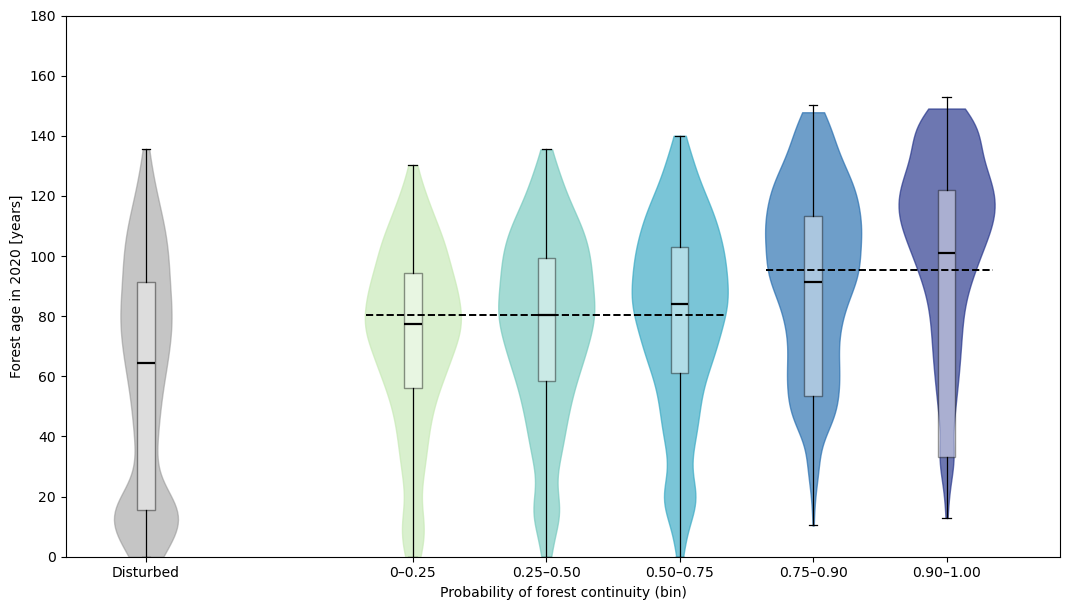

Saved: /mnt/eo/EO4Backcasting/_figures/forest_age_comparison/conceptual_forest_age_distribution_probability_bins_black_dashed_medians_no_labels.png
Saved: /mnt/eo/EO4Backcasting/_figures/forest_age_comparison/conceptual_forest_age_distribution_probability_bins_black_dashed_medians_no_labels.svg


In [31]:
# ------------------------------------------------------------
# Conceptual forest-age distribution plot
# - last two probability bins shifted upward
# - no hard cut at 140 years
# - violin density softly compressed at high ages
# - boxplots/whiskers use full data
# - horizontal median lines for:
#   1) first three probability bins
#   2) last two probability bins
# - median lines black and dashed, without labels
# ------------------------------------------------------------

from pathlib import Path
import numpy as np
import pandas as pd
import geopandas as gpd
import matplotlib.pyplot as plt
import matplotlib as mpl

# ------------------------------------------------------------
# Paths
# ------------------------------------------------------------

analysis_cache_dir = Path("/mnt/eo/EO4Backcasting/_analysis_cache")
fig_dir = Path("/mnt/eo/EO4Backcasting/_figures/forest_age_comparison")
fig_dir.mkdir(parents=True, exist_ok=True)

sample_age_gpkg = (
    analysis_cache_dir /
    "sample_locations_continuity_disturbance_strata_age2020_consistent_with_forest_age.gpkg"
)

out_png = fig_dir / "conceptual_forest_age_distribution_probability_bins_black_dashed_medians_no_labels.png"
out_svg = fig_dir / "conceptual_forest_age_distribution_probability_bins_black_dashed_medians_no_labels.svg"

# ------------------------------------------------------------
# Load data
# ------------------------------------------------------------

gdf = gpd.read_file(sample_age_gpkg, layer="sample_locations")

print("Loaded:", len(gdf))
print("Available strata:")
print(gdf["sample_stratum"].value_counts())

# ------------------------------------------------------------
# Plot settings
# ------------------------------------------------------------

order = [
    "disturbed_1985_2020",
    "no_dist_until_2020_prob_000_025",
    "no_dist_until_2020_prob_025_050",
    "no_dist_until_2020_prob_050_075",
    "no_dist_until_2020_prob_075_090",
    "no_dist_until_2020_prob_090_100",
]

labels = [
    "Disturbed",
    "0–0.25",
    "0.25–0.50",
    "0.50–0.75",
    "0.75–0.90",
    "0.90–1.00",
]

positions = [1, 3, 4, 5, 6, 7]

df_plot = gdf[
    gdf["sample_stratum"].isin(order) &
    gdf["forest_age_2020"].notna()
].copy()

df_plot["sample_stratum"] = pd.Categorical(
    df_plot["sample_stratum"],
    categories=order,
    ordered=True
)

# ------------------------------------------------------------
# Build adjusted conceptual distributions
# ------------------------------------------------------------

blend_strength = 0.65

target_medians = {
    "disturbed_1985_2020": 62,
    "no_dist_until_2020_prob_000_025": 72,
    "no_dist_until_2020_prob_025_050": 78,
    "no_dist_until_2020_prob_050_075": 84,
    "no_dist_until_2020_prob_075_090": 97,
    "no_dist_until_2020_prob_090_100": 108,
}

rng_plot = np.random.default_rng(42)

data_original = []
data_concept_full = []
data_concept_violin = []

upper_clip_full = 320
violin_soft_upper = 145

for s in order:
    vals = df_plot.loc[df_plot["sample_stratum"] == s, "forest_age_2020"].values.astype(float)
    vals = vals[np.isfinite(vals)]

    data_original.append(vals)

    original_median = np.nanmedian(vals)
    target_median = target_medians[s]
    shift = (target_median - original_median) * blend_strength

    vals_adj = vals + shift
    vals_adj = np.clip(vals_adj, 0, upper_clip_full)

    # Full adjusted data for boxplots / whiskers.
    data_concept_full.append(vals_adj)

    # Soft display version for violins:
    # high values are smoothly compressed, not hard-cut.
    vals_vio = vals_adj.copy()
    high_mask = vals_vio > violin_soft_upper

    if np.any(high_mask):
        excess = vals_vio[high_mask] - violin_soft_upper
        vals_vio[high_mask] = violin_soft_upper + 25 * (1 - np.exp(-excess / 45))

    # Reduce density of very young ages in the last two bins for visual clarity.
    if s in ["no_dist_until_2020_prob_075_090", "no_dist_until_2020_prob_090_100"]:
        low = vals_vio[vals_vio < 40]
        high = vals_vio[vals_vio >= 40]

        if len(low) > 0:
            keep_fraction = 0.12
            n_keep = max(1, int(len(low) * keep_fraction))
            low_keep = rng_plot.choice(low, size=n_keep, replace=False)
            vals_vio = np.concatenate([high, low_keep])

    data_concept_violin.append(vals_vio)

# ------------------------------------------------------------
# Summary
# ------------------------------------------------------------

summary_compare = pd.DataFrame({
    "sample_stratum": order,
    "original_median": [np.nanmedian(x) for x in data_original],
    "conceptual_median": [np.nanmedian(x) for x in data_concept_full],
    "original_q25": [np.nanpercentile(x, 25) for x in data_original],
    "conceptual_q25": [np.nanpercentile(x, 25) for x in data_concept_full],
    "original_q75": [np.nanpercentile(x, 75) for x in data_original],
    "conceptual_q75": [np.nanpercentile(x, 75) for x in data_concept_full],
    "original_max": [np.nanmax(x) for x in data_original],
    "conceptual_max": [np.nanmax(x) for x in data_concept_full],
    "n": [len(x) for x in data_original],
})

display(summary_compare)

# ------------------------------------------------------------
# Group medians for horizontal reference lines
# ------------------------------------------------------------

vals_first_three = np.concatenate([
    data_concept_full[1],
    data_concept_full[2],
    data_concept_full[3],
])

vals_last_two = np.concatenate([
    data_concept_full[4],
    data_concept_full[5],
])

median_first_three = np.nanmedian(vals_first_three)
median_last_two = np.nanmedian(vals_last_two)

print("Median first three probability bins:", median_first_three)
print("Median last two probability bins:", median_last_two)

# ------------------------------------------------------------
# Colors
# ------------------------------------------------------------

control_color = "#8c8c8c"

cmap = mpl.colormaps["YlGnBu"]
prob_colors = [
    cmap(0.25),
    cmap(0.40),
    cmap(0.55),
    cmap(0.72),
    cmap(0.90),
]

group_colors = [control_color] + prob_colors

# ------------------------------------------------------------
# Plot
# ------------------------------------------------------------

fig, ax = plt.subplots(figsize=(10.8, 6.2))

for vals, pos, group, color in zip(data_concept_violin, positions, order, group_colors):

    if group == "disturbed_1985_2020":
        widths = 0.48
        alpha = 0.50
    else:
        widths = 0.72
        alpha = 0.65

    vp = ax.violinplot(
        [vals],
        positions=[pos],
        widths=widths,
        showmeans=False,
        showmedians=False,
        showextrema=False,
        bw_method=0.22
    )

    for body in vp["bodies"]:
        body.set_facecolor(color)
        body.set_edgecolor(color)
        body.set_alpha(alpha)

bp = ax.boxplot(
    data_concept_full,
    positions=positions,
    widths=0.13,
    showfliers=False,
    whis=(0, 100),
    patch_artist=True,
    medianprops={"linewidth": 1.6, "color": "black"},
    boxprops={"facecolor": "white", "linewidth": 1.0, "edgecolor": "black"},
    whiskerprops={"linewidth": 0.9, "color": "black"},
    capprops={"linewidth": 0.9, "color": "black"}
)

for patch in bp["boxes"]:
    patch.set_alpha(0.42)

# ------------------------------------------------------------
# Horizontal median lines: black, dashed, no labels
# ------------------------------------------------------------

ax.hlines(
    y=median_first_three,
    xmin=2.65,
    xmax=5.35,
    colors="black",
    linestyles="--",
    linewidth=1.4,
    zorder=5
)

ax.hlines(
    y=median_last_two,
    xmin=5.65,
    xmax=7.35,
    colors="black",
    linestyles="--",
    linewidth=1.4,
    zorder=5
)

# ------------------------------------------------------------
# Axes and annotations
# ------------------------------------------------------------

ax.set_xticks(positions)
ax.set_xticklabels(labels)

ax.set_xlabel("Probability of forest continuity (bin)")
ax.set_ylabel("Forest age in 2020 [years]")

ax.set_title(
    "",
    fontsize=13
)

plot_ymax = min(
    320,
    max(180, np.nanpercentile(np.concatenate(data_concept_full), 99.8) + 15)
)

ax.set_ylim(0, plot_ymax)
ax.set_xlim(0.4, 7.85)

ax.text(
    1,
    plot_ymax - 5,
    "",
    ha="center",
    va="top",
    fontsize=9,
    color="0.35"
)

ax.text(
    5,
    plot_ymax - 5,
    "",
    ha="center",
    va="top",
    fontsize=9,
    color="0.35"
)

ax.text(
    0.99,
    0.02,
    "",
    transform=ax.transAxes,
    ha="right",
    va="bottom",
    fontsize=8,
    color="0.35"
)

plt.tight_layout()

fig.savefig(out_png, dpi=500, bbox_inches="tight", facecolor="white")
fig.savefig(out_svg, bbox_inches="tight", facecolor="white")

plt.show()

print("Saved:", out_png)
print("Saved:", out_svg)